In [72]:
from langgraph.graph import StateGraph , START , END
from langchain_huggingface import HuggingFaceEndpoint , ChatHuggingFace
from typing import TypedDict , Literal  , Union , Annotated
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.checkpoint.memory import MemorySaver  # stores in ram

from dotenv import load_dotenv
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel , Field
from langchain_core.messages import BaseMessage , HumanMessage , AIMessage , ToolMessage , SystemMessage
import os 
import operator # reducers
load_dotenv()


True

In [73]:
_ = HuggingFaceEndpoint(
    model ="HuggingFaceH4/zephyr-7b-beta",
    task="text-generation",
    timeout=300
)

model = ChatHuggingFace(llm = _ )


In [83]:
model = ChatGoogleGenerativeAI(model = "gemini-2.5-flash-lite")


In [84]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage] , add_messages]


In [85]:
def chat_node(state : ChatState):
    
    # take user query from state 
    messages = state['messages']
    
    # send to llm 
    result =model.invoke(messages)
    
    # response store to message as history 
    return {"messages" : [result] }


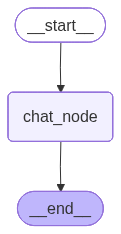

In [86]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node("chat_node" , chat_node)

graph.add_edge(START , "chat_node")
graph.add_edge("chat_node" , END)

chatbot  = graph.compile(checkpointer=checkpointer)
chatbot


In [ ]:
# intial_state = {
#     "messages" : [
#         SystemMessage(content="You are a helpful assistant. Answer strictly in 1 sentences. Be concise and to the point."),
#                   HumanMessage(content="What is capital of India")]
# }



In [ ]:
# output = chatbot.invoke(intial_state)


ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
# output


{'messages': [SystemMessage(content='You are a helpful assistant. Answer strictly in 1 sentences. Be concise and to the point.', additional_kwargs={}, response_metadata={}, id='24242900-c360-499d-afe3-8420f7e6c64a'),
  HumanMessage(content='What is capital of India', additional_kwargs={}, response_metadata={}, id='ba22ab11-a22c-4156-a4c3-0018d4e5f5eb'),
  AIMessage(content="The capital city of India is New Delhi, which is a territorial union city and also serves as the administrative center of the National Capital Territory of Delhi within the country's federal structure. However, New Delhi is not a state, as it does not hold the same level of administrative authority as other states; rather, it falls under the authority of the central government of India. The largest city and financial hub of India by both population and area is Mumbai (Bombay until 1996), located in the state of Maharashtra.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_

In [60]:
output['messages'][-1].content


"The capital city of India is New Delhi, which is a territorial union city and also serves as the administrative center of the National Capital Territory of Delhi within the country's federal structure. However, New Delhi is not a state, as it does not hold the same level of administrative authority as other states; rather, it falls under the authority of the central government of India. The largest city and financial hub of India by both population and area is Mumbai (Bombay until 1996), located in the state of Maharashtra."

In [87]:
thread_id = "1"
while True: 
    
    user_message = input("Type here : ")
    
    print("User :" , user_message)
    
    if user_message.strip().lower() in ['exit' , 'bye' , 'quit']:
        print("chat ended")
        break
    
    config  = {"configurable" : {"thread_id" : thread_id}}
    
    response = chatbot.invoke({
    "messages" : [
        SystemMessage(content="You are a helpful assistant. Answer strictly in 1 sentences. Be concise and to the point."),
        HumanMessage(content=user_message)
        ]
    } , config= config)
    
    print("AI : " , response['messages'][-1].content)


User : Hi my name is Crashlar 
AI :  Hello Crashlar, it's nice to meet you.
User : what is 10 by 3 
AI :  10 divided by 3 is 3 with a remainder of 1.
User : multiply result to 10 
AI :  The result of multiplying 10 by 3 is 30.
User : what is my name 
AI :  Your name is Crashlar.
User : exit 
chat ended


In [88]:
response['messages'][-1].content


'Your name is Crashlar.'

In [ ]:
chatbot.get_state(config=config)
# all message seen here with metadata 


StateSnapshot(values={'messages': [SystemMessage(content='You are a helpful assistant. Answer strictly in 1 sentences. Be concise and to the point.', additional_kwargs={}, response_metadata={}, id='49522d49-42be-4f08-a9ca-1f770d4c356b'), HumanMessage(content='Hi my name is Crashlar ', additional_kwargs={}, response_metadata={}, id='dfd22678-b670-4c9c-9b0a-b76ca81bd6f6'), AIMessage(content="Hello Crashlar, it's nice to meet you.", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b82c9-ac10-7102-b31b-da92cfef3131-0', usage_metadata={'input_tokens': 28, 'output_tokens': 12, 'total_tokens': 40, 'input_token_details': {'cache_read': 0}}), SystemMessage(content='You are a helpful assistant. Answer strictly in 1 sentences. Be concise and to the point.', additional_kwargs={}, response_metadata={}, id='0dec16b3-24f4-4b3a-a2cd-e1bcfcefcd22'), HumanMessage(content='what 